In [ ]:
!pip install -U pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 8.0 MB/s eta 0:00:00


In [ ]:
import pysr

[juliapkg] Found dependencies: /usr/local/lib/python3.11/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.11/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.11/dist-packages/pysr/juliapkg.json
[juliapkg] Locating Julia ^1.10.3
[juliapkg] Using Julia 1.10.9 at /usr/local/bin/julia
[juliapkg] Using Julia project at /root/.julia/environments/pyjuliapkg
[juliapkg] Writing Project.toml:
             [deps]
             PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
             OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
             SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
             Serialization = "9e88b42a-f829-5b0c-bbe9-9e923198166b"
             [compat]
             PythonCall = "=0.9.26"
             OpenSSL_jll = "~3.0"
             SymbolicRegression = "~1.11"
             Serialization = "^1"
[juliapkg] Installing packages:
             import Pkg
             

In [ ]:
import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split

In [ ]:
# Load your dataset from a CSV file
import pandas as pd
df = pd.read_csv("/content/all_data_Nu_Nw.csv")  # Replace with your file path

# Split dataset into input features (X) and target variable (y)
# Assumes the last column is the target
X = df.iloc[:, 0:6].values
y = df.iloc[:, -1].values

In [ ]:
print(y)

[-0.03361317 -0.09078047 -0.14762697 -0.20418414 -0.26051629 -0.31671841
 -0.37291553 -0.42926412 -0.48595586 -0.54322323 -0.6013461  -0.6606578
 -0.72154855 -0.78446358 -0.84989287 -0.9183494  -0.99033303 -1.06627857
 -1.14648905 -1.31979723 -0.46388012 -0.42098455 -0.37784336 -0.33466821
 -0.29157665 -0.24861154 -0.20575697 -0.16294996 -0.12008809 -0.07703335
  0.0103803   0.05519095  0.10109804  0.14841238  0.19746779  0.24860738
  0.30216428  0.35843845  0.4176713   0.48002137  0.07855298  0.05973146
  0.03313027  0.00530093 -0.01826166 -0.02713742 -0.03750713 -0.03749564
 -0.02813927 -0.01167754 -0.03114819 -0.03112336 -0.03261828 -0.03308057
 -0.03156562 -0.02938735 -0.02792224 -0.02683009 -0.02472104 -0.02184062
  0.01646197  0.06653869  0.11648997  0.16618256  0.21548107  0.26425382
  0.31238088  0.35976473  0.40634342  0.45210665  0.49711388  0.54151357
  0.58556128  0.6296333   0.6742308   0.71996843  0.76754039  0.81765849
  0.87096049  0.92789462  0.52380835  0.45281516  0.

In [ ]:
#print(X)

In [ ]:
np.random.seed(0)

# Define and fit the model
model = PySRRegressor(
    niterations=100,
    binary_operators=["+", "-", "*"],  # allow only polynomial operations
    unary_operators=["square", "cube", "exp", "sin", "cos"],  # optional: include power terms
    extra_sympy_mappings={
        "square": lambda x: x**2,
        "cube": lambda x: x**3
    },
    loss="loss(x, y) = (x - y)^2",
    maxsize=20,
    model_selection="best",  # choose simplest best model
    #verbose=True,
)

# Fit the model
model.fit(X, y)

# Print discovered equations
print(model)

/usr/local/lib/python3.11/dist-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 1.000e+05
Progress: 610 / 3100 total iterations (19.677%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.266e-01  0.000e+00  y = -0.077488
3           1.850e-01  1.013e-01  y = cos(exp(x₀))
4           1.769e-01  4.476e-02  y = cube(cos(cube(x₅)))
5           1.145e-01  4.347e-01  y = (x₀ * -5.208) - x₄
6           1.105e-01  3.594e-02  y = sin(sin(cube(x₀ + x₄)))
7           8.322e-02  2.836e-01  y = sin(cube(x₀ + x₄) * 0.32998)
8           7.692e-02  7.868e-02  y = 2.7695 - cube(x₅ - (1.1139 - x₀))
9           2.284e-02  1.214e+00  y = sin(cube((x₄ + 1.5711) + (x₅ + x₀)))
11          2.244e-02  8.849e-03  y = sin(cube(x₄ + ((x₅ + x₀) + 1.566))) + -0.026096
13          2.232e-02  2.672e-03  y = sin(cube((x₅ + (1.7333 + x₀)) + (x₄ + -0.16732)))

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.266e-01  0.000e+00  y = -0.077488
3           1.850e-01  1.013e-01  y = cos(exp(x₀))
4           1.366e-01  3.035e-01  y = sin(x₀ * 6.2175)
5           1.145e-01  1.759e-01  y = (x₀ * -5.208) - x₄
6           8.138e-02  3.418e-01  y = sin(square(x₄ + cube(x₀)))
7           7.419e-02  9.249e-02  y = sin(cube((x₀ + 3.5765) + x₄))
8           6.214e-02  1.774e-01  y = sin(((x₀ + x₄) - x₁) * -4.8003)
9           2.284e-02  1.001e+00  y = sin(cube(((x₅ + 1.5711) + x₄) + x₀))
11          4.010e-03  8.697e-01  y = (((x₀ + x₄) - x₁) * -5.4136) + (x₅ * -7.067)
13          3.153e-03  1.202e-01  y = (x₅ * -7.9793) + (2.251 + (((x₄ - x₁) + x₀) * -5.2514)...
                                      )
15          1.355e-03  4.222e-01  y = (((x₅ * 3.1078) + -11.053) * (x₀ + (x₄ - x₁))) - (x₀ +...
                                       12.11)
17     

In [ ]:
model.sympy()

x5*(x5*2.694353 - 7.807613)*(x0 - x1 + x4) - (x0 + 12.107477)

In [1]:
def symbolic_function(Z):
    """
    x: list or array-like with at least 6 elements [x0, x1, x2, x3, x4, x5]
    """
    return Z[5] * (Z[5] * 2.694353 - 7.807613) * (Z[0] - Z[1] + Z[4]) - (Z[0] + 12.107477)


In [ ]:
print(y)

[-0.03361317 -0.09078047 -0.14762697 -0.20418414 -0.26051629 -0.31671841
 -0.37291553 -0.42926412 -0.48595586 -0.54322323 -0.6013461  -0.6606578
 -0.72154855 -0.78446358 -0.84989287 -0.9183494  -0.99033303 -1.06627857
 -1.14648905 -1.31979723 -0.46388012 -0.42098455 -0.37784336 -0.33466821
 -0.29157665 -0.24861154 -0.20575697 -0.16294996 -0.12008809 -0.07703335
  0.0103803   0.05519095  0.10109804  0.14841238  0.19746779  0.24860738
  0.30216428  0.35843845  0.4176713   0.48002137  0.07855298  0.05973146
  0.03313027  0.00530093 -0.01826166 -0.02713742 -0.03750713 -0.03749564
 -0.02813927 -0.01167754 -0.03114819 -0.03112336 -0.03261828 -0.03308057
 -0.03156562 -0.02938735 -0.02792224 -0.02683009 -0.02472104 -0.02184062
  0.01646197  0.06653869  0.11648997  0.16618256  0.21548107  0.26425382
  0.31238088  0.35976473  0.40634342  0.45210665  0.49711388  0.54151357
  0.58556128  0.6296333   0.6742308   0.71996843  0.76754039  0.81765849
  0.87096049  0.92789462  0.52380835  0.45281516  0.

In [2]:

# Define your custom function
# custom_function(Z):
#    return (Z[0]*(-4.3583193)
#            + (Z[4] - 0.93447506)**2
#            + (Z[1] - Z[5] + 0.24600449)**3
#            - 3.8498328)
import pandas as pd

# Load dataset
df = pd.read_csv("/content/all_data_Nu_Nw.csv")  # Replace with your actual path

# Extract input features (first 6 columns)
X = df.iloc[:, 0:6].values
y = df.iloc[:, -1].values

# Compute results and store them
results = []
for row in X:
    results.append(symbolic_function(row))

# Create a new DataFrame to save
output_df = pd.DataFrame({
    'Symbolic_Result': results
})


In [3]:
df2 = pd.read_csv("/content/Validation_Nu.csv")  # Replace with your actual path
X_val = df2.iloc[:, 0:6].values
y_val = df2.iloc[:, -1].values

In [4]:
y_val

array([-0.31634205, -0.54316751, -0.60206044, -0.84887826, -1.06664453,
       -0.29265741,  0.14917399,  0.02693236,  0.00178199, -0.01902656,
       -0.0308589 , -0.03255728, -0.02198557,  0.91994544,  0.03189004])

In [5]:
# Compute results and store them
results_val = []
for row in X_val:
    results_val.append(symbolic_function(row))

# Create a new DataFrame to save
output_df = pd.DataFrame({
    'Symbolic_Result': results_val
})


In [6]:
results_val

[np.float64(-0.3210513000000006),
 np.float64(-0.5545638599999982),
 np.float64(-0.6129419999999985),
 np.float64(-0.8464545599999997),
 np.float64(-1.0215889799999989),
 np.float64(-0.3194294400000004),
 np.float64(0.16435196000000118),
 np.float64(-0.029160599999999093),
 np.float64(-0.029160599999999093),
 np.float64(-0.029160599999999093),
 np.float64(-0.029160599999999093),
 np.float64(-0.029160599999999093),
 np.float64(-0.029160599999999093),
 np.float64(0.9384021999999987),
 np.float64(0.04735364221999738)]

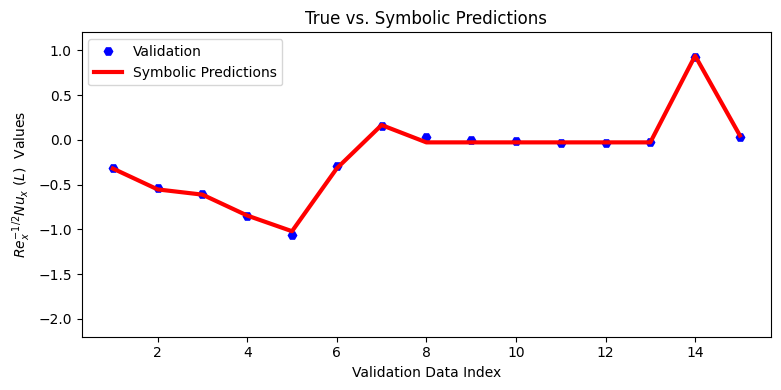

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Point-wise error
#errors = y_true - y_pred
# Plotting

# Create shifted index starting from 1
index = np.arange(1, len(y_val)+1)
plt.figure(figsize=(8, 4))
plt.plot(index, y_val, marker='H', linestyle='None', color='blue', label='Validation')
plt.plot(index, results_val, marker='None', linestyle='-', color='red', linewidth=3, label='Symbolic Predictions')
plt.axhline(0, color='gray', linestyle='None')
plt.xlabel('Validation Data Index')
plt.ylabel('${Re}_x^{-1/2}Nu_x$ $(L)$  Values')
#plt.ylabel('Error (True - Predicted)')
plt.title('True vs. Symbolic Predictions')
plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.ylim([-2.2, 1.2])
plt.savefig("True_vs_symbolic_Nu_Val.eps", format="eps")
plt.show()

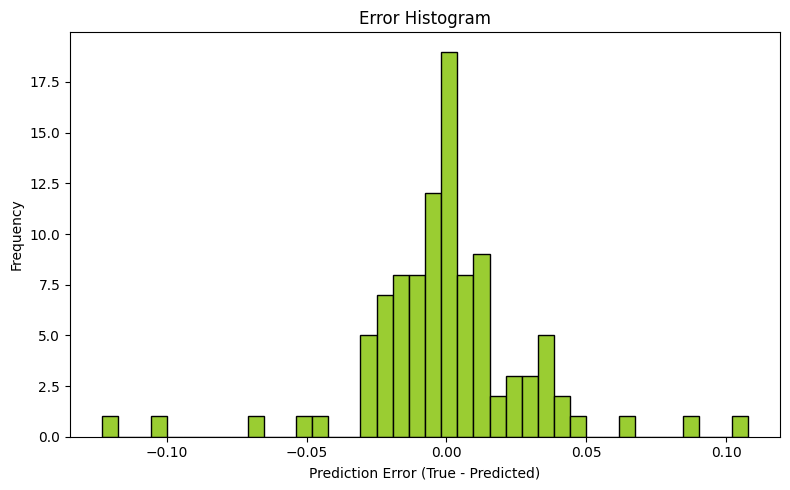

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Sample data
y_true = y
y_pred = results

errors=y_true-y_pred
# Plotting
# Plot error histogram
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=40, edgecolor='black', color='yellowgreen')
plt.xlabel('Prediction Error (True - Predicted)')
plt.ylabel('Frequency')
plt.title('Error Histogram')
#plt.grid(True)
plt.tight_layout()
plt.savefig("Error_Histogram_Nu.eps", format="eps")
plt.show()

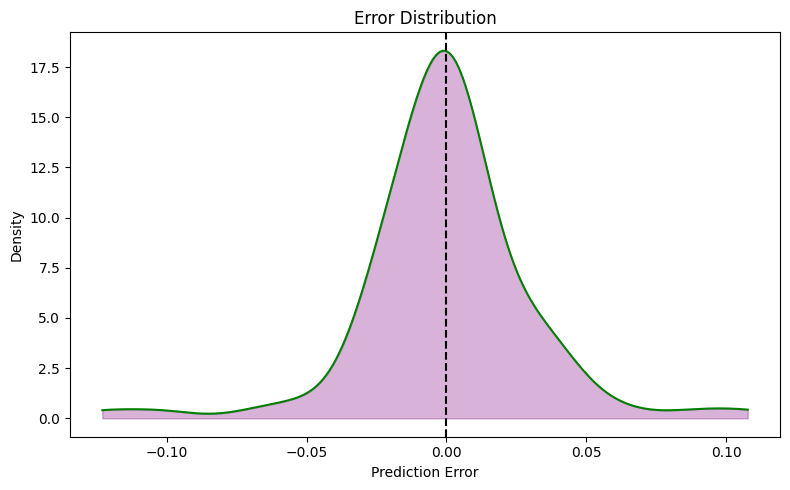

In [ ]:
from scipy.stats import gaussian_kde

# KDE for error distribution
density = gaussian_kde(errors)
xs = np.linspace(min(errors), max(errors), 200)

plt.figure(figsize=(8, 5))
plt.plot(xs, density(xs), color='green')
plt.fill_between(xs, density(xs), alpha=0.3, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.title('Error Distribution') #  (KDE= Kernel Density Estimation)
plt.xlabel('Prediction Error')
plt.ylabel('Density')
#plt.grid(True)
plt.tight_layout()

# Save the figure in EPS format
plt.savefig("error_distribution_Nu.eps", format="eps")
plt.show()


In [ ]:
def custom_function(Z):
    return (Z[0]*(-4.3583193)
            + (Z[4] - 0.93447506)**2
            + (Z[1] - Z[5] + 0.24600449)**3
            - 3.8498328)

Z1 = [0.5, 0.5, 2, 1, -2.6, 2]
Z2 = [0.51, 0.5, 2, 1, -2.6, 2]
Z3 = [0.7, 0.5, 2, 1, -2.6, 2]
print(custom_function(Z3))
## Example: generate 10 different x vectors and store function values
#function_values = []
#for i in range(10):
#    # Example x vector of 6 elements; change this logic as needed
#    Z = [i + j for j in range(6)]  # e.g., [i, i+1, i+2, ..., i+5]
#
#    f_val = custom_function(Z)
#    function_values.append(f_val)

# Print results
#for i, val in enumerate(function_values):
#    print(f"f(x) at index {i}: {val}")


In [ ]:
Z1 = [0.5, 0.5, 2, 1, -2.6, 2]
Z2 = [0.51, 0.5, 2, 1, -2.6, 2]
Z3 = [0.7, 0.5, 2, 1, -2.6, 2]
print(custom_function(Z3))

3.6199437574766837


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/all_data_cf_fnl.csv")  # Replace with your actual path

# Extract input features (first 6 columns)
X = df.iloc[:, 0:6].values
y = df.iloc[:, -1].values
# Define your custom function
def custom_function(Z):
    return (Z[0]*(-4.3583193)
            + (Z[4] - 0.93447506)**2
            + (Z[1] - Z[5] + 0.24600449)**3
            - 3.8498328)

# Compute results and store them
results = []
for row in X:
    results.append(custom_function(row))

# Create a new DataFrame to save
output_df = pd.DataFrame({
    'Symbolic_Result': results
})

# Save to CSV
output_df.to_csv("custom_function_output.csv", index=False)
print("Results saved to custom_function_output.csv")


Results saved to custom_function_output.csv


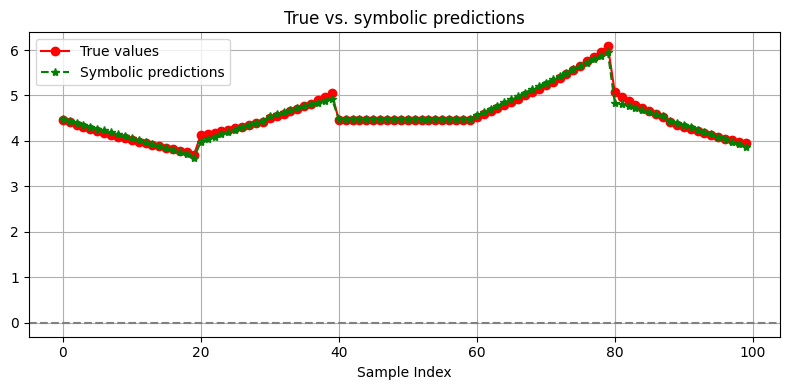

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
y_true = y
y_pred = results
# Point-wise error
#errors = y_true - y_pred
# Plotting
plt.figure(figsize=(8, 4))
plt.plot(y_true, marker='o', linestyle='-', color='red', label='True values')
plt.plot(y_pred, marker='*', linestyle='--', color='green', label='Symbolic predictions')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Sample Index')
#plt.ylabel('Error (True - Predicted)')
plt.title('True vs. symbolic predictions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# MSE for True - Symbolic_predicted
#y-results
import numpy as np

mse = np.mean((y-results) ** 2)
print("MSE:", mse)

MSE: 0.0032542970245511694


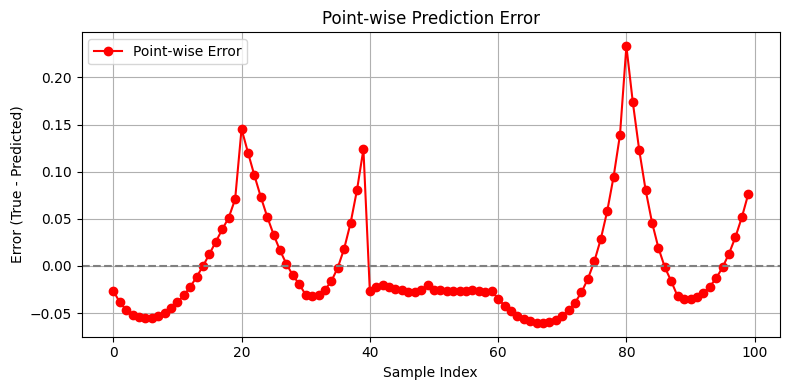

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
y_true = y
y_pred = results
# Point-wise error
errors = y_true - y_pred
# Plotting
plt.figure(figsize=(8, 4))
plt.plot(errors, marker='o', linestyle='-', color='red', label='Point-wise Error')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Sample Index')
plt.ylabel('Error (True - Predicted)')
plt.title('Point-wise Prediction Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

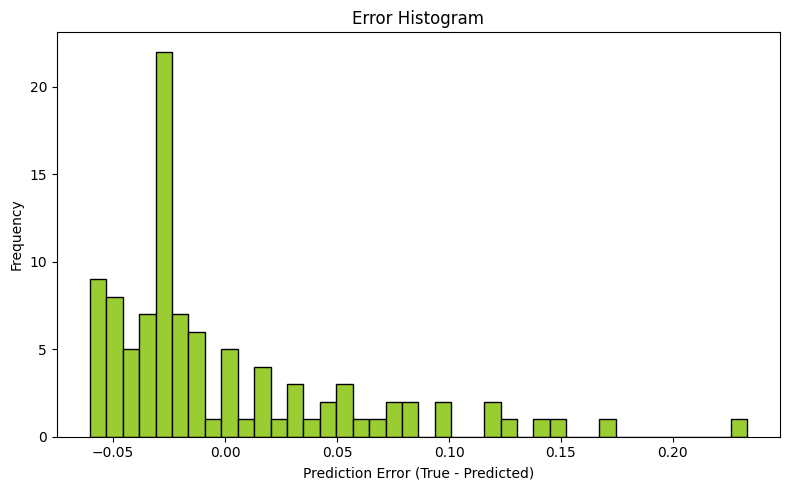

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Plot error histogram
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=40, edgecolor='black', color='yellowgreen')
plt.xlabel('Prediction Error (True - Predicted)')
plt.ylabel('Frequency')
plt.title('Error Histogram')
#plt.grid(True)
plt.tight_layout()
plt.show()


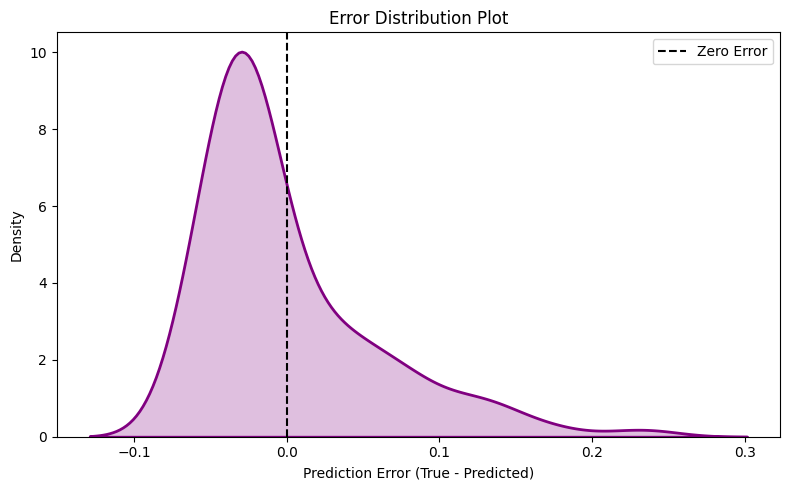

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Compute errors
#errors = y_true - y_pred

# Plot error distribution using KDE
plt.figure(figsize=(8, 5))
sns.kdeplot(errors, fill=True, color='purple', linewidth=2)
plt.axvline(0, color='black', linestyle='--', label='Zero Error')
plt.title('Error Distribution Plot')
plt.xlabel('Prediction Error (True - Predicted)')
plt.ylabel('Density')
plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.show()


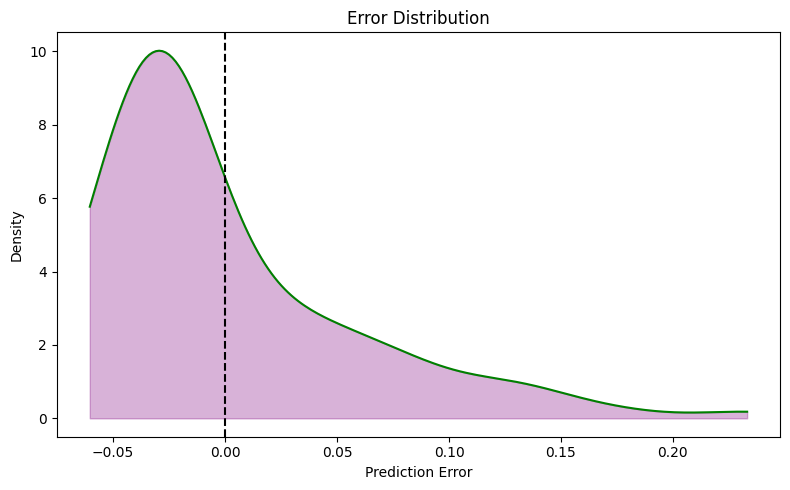

In [ ]:
from scipy.stats import gaussian_kde

# KDE for error distribution
density = gaussian_kde(errors)
xs = np.linspace(min(errors), max(errors), 200)

plt.figure(figsize=(8, 5))
plt.plot(xs, density(xs), color='green')
plt.fill_between(xs, density(xs), alpha=0.3, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.title('Error Distribution') #  (KDE= Kernel Density Estimation)
plt.xlabel('Prediction Error')
plt.ylabel('Density')
#plt.grid(True)
plt.tight_layout()

# Save the figure in EPS format
#plt.savefig("error_distribution.eps", format="eps")
plt.show()
